# Differential Privacy for ML Course - Lab #3

*Master IASD, PSL - O. Cappé, February 2025*

This third lab is devoted to DP mechanisms for the linear regression model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error 
# Root mean squared error
def root_mean_squared_error(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

## The Dataset

For this lab, we will use the sames dataset as in Lab #2. 

In [2]:
openml = False
if (openml):
    data = fetch_openml(name='Indian-Liver-Patient-Records', version=2, as_frame=True).frame    # Load dataset from OpenML as a Pandas data rrame
else:
    # Backup solution, reading from a local CSV file
    data = pd.read_csv('lab2_indian-liver.csv')
data.head(10)     # Print the first 10 rows of the dataset

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.4,1
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.3,1
6,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.0,1
7,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.1,1
8,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.2,2
9,55,Male,0.7,0.2,290,53,58,6.8,3.4,1.0,1


Better not center by the mean of the value although it would simplify the least squares problem.


## Linear Regression

We will consider simple (i.e., one-dimensional) linear regression with `Albumin` as the regressor $x$ and `Total_Proteins` as the target $y$. We will consider that the data can be approximately normalized by the following transform, making in possible to assume that all $x_i$ and $y_i$ are in $(-1,1)$.

In [3]:
x = (np.array(data['Albumin']).reshape(-1, 1)-3)/3
y = (np.array(data['Total_Proteins']).reshape(-1, 1)-5)/5

We scale two columns approx bw -1 and +1. This is not exactly centered. They are not summing to 0. 

In linear regression because the datra is not centered it is important to use intercept.(predicted value of the dependent variable when the independent variables are 0)

We convert to have each regressor to be 2-dimensional.




## Linear Regression
Given $\{(x_i,y_i)\}_{i=1}^n$, the task is to find the parameters $(\beta_1, \beta_0)$ to fit the following linear model,
$y = \beta_1 x + \beta_0$.

Let $X$ denote the $n\times 2$ matrix whose first column is composed of $x_1, \ldots, x_n$ and second column composed of all ones. Let $\beta = [\beta_1 \ \beta_0]^T$. Recall that the ordinary least squares (OLS) solution to the problem is the following.

$$
\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty
=   \begin{bmatrix} 
    \sum_i x_i^2 & \sum_i x_i\\
    \sum_i x_i & n
    \end{bmatrix}^{-1}
    \begin{bmatrix} 
    \sum_i x_iy_i\\
    \sum_i y_i
    \end{bmatrix}
$$.


### Linear Regression with OLS

The following code block implements the function `linreg` that computes $\beta$ using the OLS formula above.

In [4]:
def linreg(x,y):
    """
    Performs linear regression using Ordinary Least Squares (OLS).
    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    Returns:
    numpy.ndarray: A 1D array containing the coefficients (slope, intercept) of the linear regression model.
    """

    n = x.size

    # Compute statistics
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.matmul(x.T, y).item()
    sum_x2 = np.matmul(x.T, x).item()
    
    # Solve the normal equations
    xTx = np.array([[sum_x2, sum_x], [sum_x, n]])
    xTy = np.array([[sum_xy], [sum_y]])
    beta_ols = np.linalg.solve(xTx, xTy)

    return beta_ols

The following code blocks illustrate the result of the `linreg` function applied to the data.

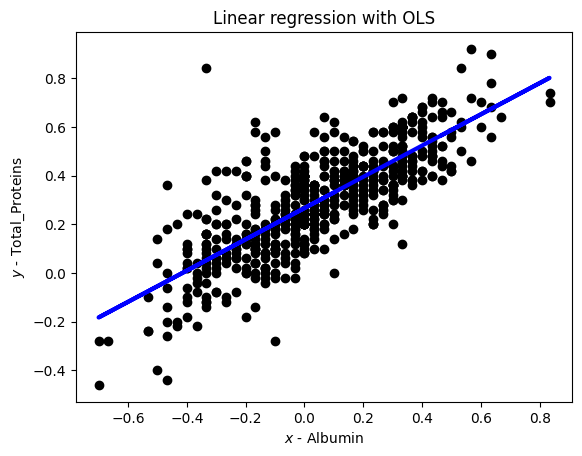

In [5]:
def plot_linreg(x, y, beta, title):
    yhat = beta[0]*x + beta[1]
    plt.scatter(x, y,  color='black')
    plt.plot(x, yhat, color='blue', linewidth=3)
    plt.xlabel(r'$x$ - Albumin')
    plt.ylabel(r'$y$ - Total_Proteins')
    plt.title(title)
    plt.show()

beta = linreg(x,y)
plot_linreg(x, y, beta,'Linear regression with OLS')

### L3.1 Perturbed Least Squares with Gaussian Mechanism

Given that the OLS solution is a function of the four statistics $\sum_i x_i^2, \sum_i x_i, \sum_i x_i y_i$ and $\sum_i y_i$, we will first consider using the Gaussian mechanism to perturb these statistics. **How should the scale of the Gaussian noise $\sigma$ be set so as to achieve $(\epsilon,\delta)$-DP with $\delta = 1/n$? Implement as `dp_linreg_pertub` a variant of  the `linreg`function above that implements this mechanism.** 

To apply the **Gaussian Mechanism** for differential privacy, we need to determine the **global sensitivity** of the four statistics used in ordinary least squares (OLS):

1. \( S_1 = \sum_{i=1}^{n} x_i^2 \) → Sensitivity: **1**
2. \( S_2 = \sum_{i=1}^{n} x_i \) → Sensitivity: **2**
3. \( S_3 = \sum_{i=1}^{n} x_i y_i \) → Sensitivity: **2**
4. \( S_4 = \sum_{i=1}^{n} y_i \) → Sensitivity: **2**

Given that the dataset is **bounded** with \( x_i, y_i \in [-1,1] \), the worst-case change when adding or removing a single data point is computed using the **L2 norm**:

\[
\Delta S = \sqrt{(1)^2 + (2)^2 + (2)^2 + (2)^2} = \sqrt{13}
\]




In [18]:
def dp_linreg_perturb(x, y, eps):
    """
    Performs (eps,1/n)-DP linear regression using Gauss Perturbed Least Squares.
    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    eps (positive real): Privacy budget
    Returns:
    numpy.ndarray: A 1D array containing the coefficients (slope, intercept) of the linear regression model.
    """
    n = x.size

    # Compute original statistics
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.matmul(x.T, y).item()
    sum_x2 = np.matmul(x.T, x).item()

    # Compute noise scale based on Gaussian mechanism (delta = 1/n)
    delta = 1 / n
    sensitivity = np.sqrt(13)  

    sigma = (np.sqrt(2 * np.log(1 / delta)) * sensitivity) / eps

    # Add Gaussian noise to statistics
    sum_x2 += np.random.normal(0, sigma)
    sum_x += np.random.normal(0, sigma)
    sum_xy += np.random.normal(0, sigma)
    sum_y += np.random.normal(0, sigma)

    # Solve noisy normal equations
    xTx = np.array([[sum_x2, sum_x], [sum_x, n]])
    xTy = np.array([[sum_xy], [sum_y]])
    beta_gauss = np.linalg.solve(xTx, xTy)

    return beta_gauss


In the following code block, test the `dp_linreg_pertub` and compare its output with ordinary least squares.

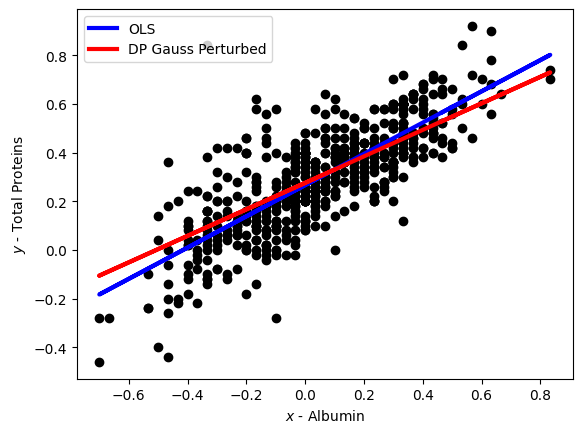

In [20]:
def plot_compar_linreg(x, y, beta1, title1, beta2, title2):
    yhat1 = beta1[0]*x + beta1[1]
    yhat2 = beta2[0]*x + beta2[1]

    plt.scatter(x, y,  color='black')
    plt.plot(x, yhat1, color='blue', linewidth=3, label=title1)
    plt.plot(x, yhat2, color='red', linewidth=3, label=title2)
    plt.legend(loc="upper left")
    plt.xlabel(r'$x$ - Albumin')
    plt.ylabel(r'$y$ - Total Proteins')
    plt.show()

eps = 3
plot_compar_linreg(x, y, linreg(x,y), 'OLS', dp_linreg_perturb(x, y, eps), 'DP Gauss Perturbed')

To measure the accuracy of the mechanism, we compute the median root mean squared error (RMSE) over multiple runs of the mechanism.

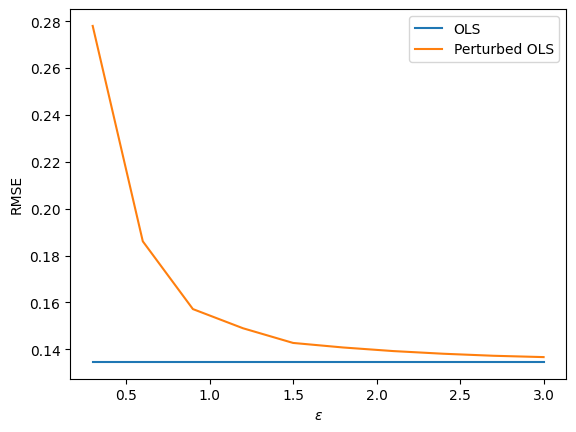

In [21]:
num_iter = 1000
eps_arr = np.linspace(0.3, 3, num=10)

beta_ols = linreg(x,y)
yhat_ols = beta_ols[0]*x + beta_ols[1]
rmse_ols = root_mean_squared_error(y, yhat_ols)*np.ones_like(eps_arr)
rmse = np.zeros((eps_arr.size, num_iter))

for i, eps in enumerate(eps_arr):
    for j in range(num_iter):
        beta = dp_linreg_perturb(x, y, eps)
        yhat = beta[0]*x + beta[1]   
        rmse[i][j] = root_mean_squared_error(y, yhat)

fig = plt.figure()
plt.plot(eps_arr, rmse_ols, label='OLS')
plt.plot(eps_arr, np.median(rmse, axis=1), label='Perturbed OLS')
plt.legend(loc="upper right")
plt.xlabel("$\epsilon$")
plt.ylabel("RMSE")
plt.show()

NB: As epsilon increases, the RMSE gradually approaches the OLS RMSE, since less noise is added.

### L3.2 Perturbed Gradient Descent

#### Gradient Descent

For this question, we will estimate $\hat{\beta}$ using gradient descent. Recall that in gradient descent, we start from an arbitraty initialization $\hat{\beta}_0$ for $\hat{\beta}$ and update $\hat{\beta}$ using the following equation.

$\hat{\beta}_{t+1} = \hat{\beta}_t - \gamma \nabla L(\hat{\beta}_t)$,

where $t$ is the iteration number running from $1$ to $T$ (maximum number of gradient steps), $\alpha$ is the step-size and $\nabla L(\hat{\beta}_t)$ is the gradient of the loss

$L(\beta) = \frac{1}{n} \sum_{i=1}^n (y_i - (\beta_0 x + \beta_1))^2$

evaluated at $\hat{\beta}_t$.

The following code block, implements the function `linreg_gd` that computes $\beta$ using gradient descent. Note that `linreg_gd` returns a list of $\hat{\beta}_t$ for each step $t$ of the gradient descent.

to calculate estimate the gradient it's better to:
 see taylor exp of first order
 delta beta * gradient = beta vector with perturbation
 

In [24]:
def linreg_gd(x, y, step_size, num_steps):
    '''
    Performs linear regression using gradient descent.
    Parameters:
    x (array of shape (n, 1)): Regressor
    y (array of shape (n, 1)): Target
    step_size (positive float): Step size for gradient descent
    num_steps (positive int (positive): Number of gradient descent steps
    Returns
    beta_list : list of length num_steps, where each element is an array of shape (2, 1)
        beta_list[t] is the estimate beta at step t
        beta_list[t][0] is the slope
        beta_list[t][1] is the y-intercept
    '''      

    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    for i in range(num_steps):
        yhat = beta[0]*x + beta[1] # slope * x + intercept
        grad = np.zeros_like(beta)
        grad[0] = -2*np.mean((y - yhat)*x)
        grad[1] = -2*np.mean(y - yhat)
        beta = beta - step_size*grad
        beta_list.append(beta)

    return beta_list

stepsize decreasing - it will not need to change the way we scale the norm.

we just need to bound the sensitivity of the norm of the gradient.
the nb if iter will have an impact
but stepsize value doesnt have an impact 
but we can experiment with stepsize

the norm of the gradient are bounded.

bound grad = 2 * bound on the object yi - BetaT (xi,1)) (xi,1)

even to have smth as simple and assuming grad are bounded We HAVE to assume that the parameters (beta) are also bounded. 

we will not do projection but we use assumption (Q2.4) as well that beta are in [-1,1] 

we need this to bound sensitivty of Gradient : assume params are bounded



The following code block illustrates the convergence of gradient descent. 

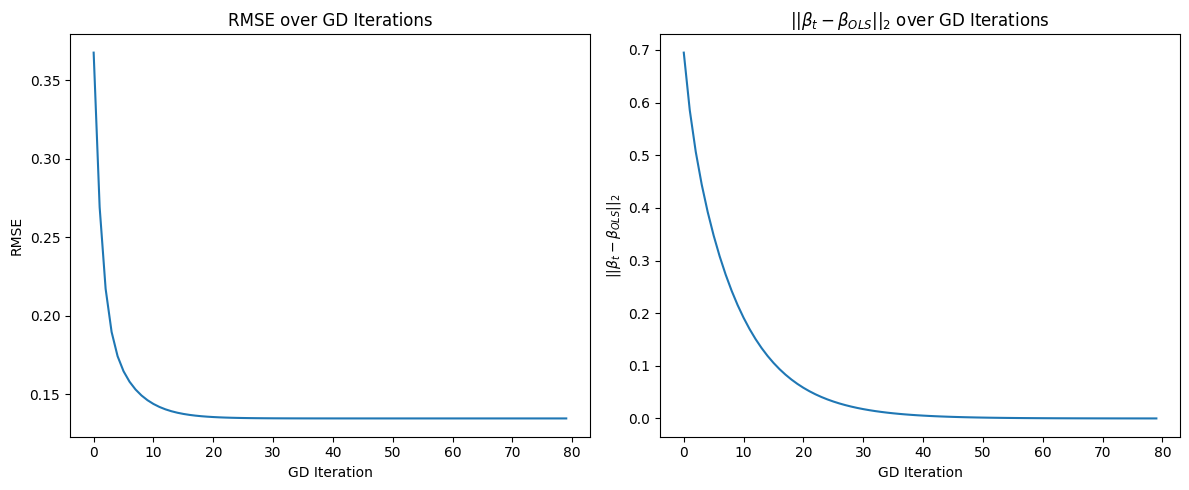

In [58]:
num_steps = 80
step_size = 0.8

beta_ols = linreg(x, y)
beta_gd = linreg_gd(x, y, step_size, num_steps)

rmse_gd = np.zeros(num_steps)
err_beta_gd = np.zeros(num_steps)

for i in range(num_steps):
    yhat = beta_gd[i][0]*x + beta_gd[i][1]
    rmse_gd[i] = root_mean_squared_error(y, yhat)
    err_beta_gd[i] = np.linalg.norm(beta_gd[i] - beta_ols)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(rmse_gd)
ax1.set_xlabel('GD Iteration')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE over GD Iterations')

ax2.plot(err_beta_gd)
ax2.set_xlabel('GD Iteration')
ax2.set_ylabel(r'$||\beta_t - \beta_{OLS}||_2$')
ax2.set_title(r'$||\beta_t - \beta_{OLS}||_2$ over GD Iterations')

plt.tight_layout()
plt.show()

with only 10 iterations we're not close the the least squares solution (far from 0)



#### Q2.4 Differentially Private Gradient Descent (DP-GD)

For this question we will assume that $\hat{\beta}_0, \hat{\beta}_1 \in [-1,1]$. **Bound the $L^2$ sensitivity of the gradient under this assumption and write a function `dp_linreg_gd`(following the code of `linreg_gd`) with adds Gaussian perturbation to each gradient update and is globally $(\epsilon,\delta)$-DP with $\delta=1/n$. You should justify the sensitivity computation as well as the use of the DP budget.**

To ensure (ε, δ)-Differential Privacy, we bound the **L2 sensitivity** of the gradient.  
From the gradient descent update:

$
\beta_{t+1} = \beta_t - \gamma \nabla L
$

the worst-case gradient shift when removing one data point is:

$
\| \Delta \nabla L \|_2 = \sqrt{\left(\frac{6}{n}\right)^2 + \left(\frac{6}{n}\right)^2} = \frac{6\sqrt{2}}{n}.
$

Since DP noise accumulates over **T iterations**, the final sensitivity scales as:

$
\Delta S = \frac{6\sqrt{2}}{n} \times \sqrt{T}.
$

To ensure $(\epsilon, \delta)$-Differential Privacy, we bound the **L2 sensitivity** of the gradient under the assumption that $\hat{\beta}_0, \hat{\beta}_1 \in [-1,1]$.

The gradient of the loss function is:

$$
\nabla L(\beta) = \begin{bmatrix} -2 \frac{1}{n} \sum_{i=1}^{n} (y_i - (\beta_1 x_i + \beta_0)) x_i \\ -2 \frac{1}{n} \sum_{i=1}^{n} (y_i - (\beta_1 x_i + \beta_0)) \end{bmatrix}
$$

Given the bounded domain $x_i, y_i \in [-1,1]$, the maximum possible norm of the gradient can be computed as:

$$
\| \nabla L \|_2 \leq 4.
$$

Since noise is added at each gradient step, and we are running for $T$ iterations, the total privacy loss accumulates over steps. We use the Gaussian mechanism to ensure overall $(\epsilon, \delta)$-DP, where $\delta = 1/n$.

The noise scale is given by:

$$
\sigma = \frac{\sqrt{2.92 \log(1/\delta)} \cdot 4}{\epsilon}.
$$

This ensures that:
- **Privacy loss does not grow too fast across iterations**.
- **Noise is calibrated based on dataset size ($n$)**.
- **A smaller $\epsilon$ enforces stronger privacy but increases noise**.


$$
\epsilon_1 = \frac{\epsilon}{\sqrt{T}}
$$

This ensures that privacy loss does not grow too fast across iterations.

The **L2 sensitivity** of the gradient, given that $\hat{\beta}_0, \hat{\beta}_1 \in [-1,1]$, is:

$$
\Delta S = \frac{6\sqrt{2}}{n} \sqrt{T}
$$

Using the **Gaussian mechanism**, the noise standard deviation is:

$$
\sigma = \frac{\Delta S \cdot \sqrt{2 \log(1/\delta)}}{\epsilon_1}
$$

Substituting $\epsilon_1$ and $\delta = 1/n$:

$$
\sigma = \frac{6\sqrt{2} \cdot \sqrt{2 \log(n)} \cdot T}{n \epsilon}
$$

This allocation ensures that:
- **Noise scales correctly with iterations** ($T$).
- **Larger datasets ($n$) reduce noise**, improving model utility.
- **Stronger privacy ($\epsilon$ lower) increases noise**, reducing accuracy.

By distributing $\epsilon$ over iterations, `dp_linreg_gd` maintains **privacy while keeping noise manageable** for learning.

To ensure (ε, δ)-Differential Privacy, we bound the **L2 sensitivity** of the gradient.  
From the gradient descent update:

$$
\beta_{t+1} = \beta_t - \gamma \nabla L
$$

the worst-case gradient shift when removing one data point is:

$$
\| \Delta \nabla L \|_2 = \sqrt{\left(\frac{6}{n}\right)^2 + \left(\frac{6}{n}\right)^2} = \frac{6\sqrt{2}}{n}.
$$

Since DP noise accumulates over **T iterations**, the final sensitivity scales as:

$$
\Delta S = \frac{6\sqrt{2}}{n} \times \sqrt{T}.
$$

In [75]:
def dp_linreg_gd(x, y, step_size, num_steps, eps):
    """
    Performs (ε, δ)-DP linear regression using Gaussian Perturbed Gradient Descent.

    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    step_size (float): Step size for gradient descent.
    num_steps (int): Number of gradient descent steps.
    eps (float): Privacy budget.

    Returns:
    list: List of beta estimates at each step.
    """
    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    # Compute L2 sensitivity
    delta = 1 / n
    sensitivity = (6 * np.sqrt(2) / n) * np.sqrt(num_steps)  

    # Compute Gaussian noise scale using Rényi DP conversion
    sigma = (sensitivity * np.sqrt(2.92 * np.log(1 / delta))) / eps

    for _ in range(num_steps):
        yhat = beta[0] * x + beta[1]

        # Compute gradient
        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)

        # Add Gaussian noise to gradient
        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise

        # Update beta
        beta = beta - step_size * grad
        beta_list.append(beta)

    return beta_list





In `dp_linreg_gd`, noise is added to the gradient at each iteration to ensure $(\epsilon, \delta)$-DP. Since the method runs for $T$ iterations, the total privacy cost accumulates over steps, requiring careful budget allocation.

To maintain the **overall** privacy guarantee at $(\epsilon, \delta)$ across $T$ steps, we allocate the budget **per step** as:

$
\epsilon_1 = \frac{\epsilon}{\sqrt{T}}
$

This ensures that privacy loss does not grow too fast across iterations.

The **L2 sensitivity** of the gradient, given that $\hat{\beta}_0, \hat{\beta}_1 \in [-1,1]$, is:

$
\Delta S = \frac{6\sqrt{2}}{n} \sqrt{T}
$

Using the **Gaussian mechanism**, the noise standard deviation is:

$
\sigma = \frac{\Delta S \cdot \sqrt{2 \log(1/\delta)}}{\epsilon_1}
$

Substituting $\epsilon_1$ and $\delta = 1/n$:

$
\sigma = \frac{6\sqrt{2} \cdot \sqrt{2 \log(n)} \cdot T}{n \epsilon}
$

This allocation ensures that:
- **Noise scales correctly with iterations** ($T$).
- **Larger datasets ($n$) reduce noise**, improving model utility.
- **Stronger privacy ($\epsilon$ lower) increases noise**, reducing accuracy.

By distributing $\epsilon$ over iterations, `dp_linreg_gd` maintains **privacy while keeping noise manageable** for learning.


The following code block, test the `dp_linreg` function and plots the convergence of the sequence of linear regression parameter estimates. **You should run it a few times to get an idea of the variability**.

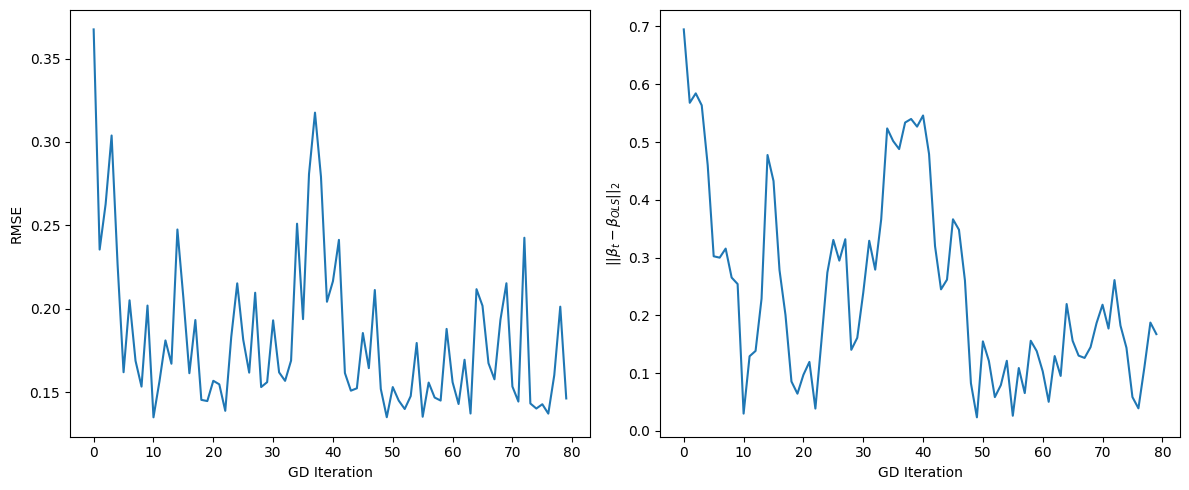

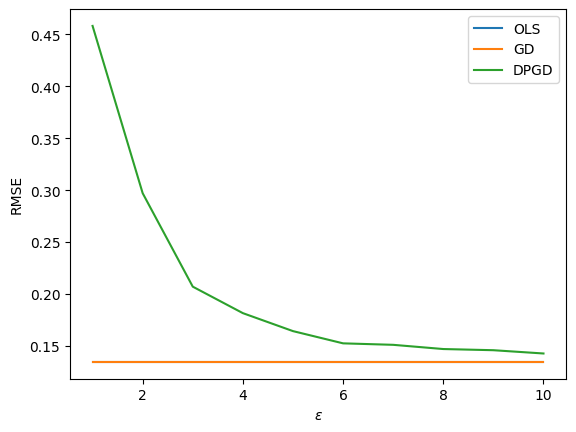

In [76]:
eps = 5
num_steps = 80
beta_list_dpgd = dp_linreg_gd(x, y, step_size, num_steps, eps)
rmse_dpgd = np.zeros(num_steps)
err_beta_dpgd = np.zeros(num_steps)
for i in range(num_steps):
    yhat = beta_list_dpgd[i][0]*x + beta_list_dpgd[i][1]
    rmse_dpgd[i] = root_mean_squared_error(y, yhat)
    err_beta_dpgd[i] = np.linalg.norm(beta_list_dpgd[i] - beta_ols)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(rmse_dpgd)
ax1.set_xlabel('GD Iteration')
ax1.set_ylabel('RMSE')

ax2.plot(err_beta_dpgd)
ax2.set_xlabel('GD Iteration')
ax2.set_ylabel(r'$||\beta_t - \beta_{OLS}||_2$')

plt.tight_layout()
plt.show()

beta_ols = linreg(x, y)
yhat_ols = beta_ols[0]*x + beta_ols[1]
rmse_ols = root_mean_squared_error(y, yhat_ols)*np.ones_like(eps_arr)

beta_gd = linreg_gd(x, y, step_size, num_steps)[-1]
yhat_gd = beta_gd[0]*x + beta_gd[1]
rmse_gd = root_mean_squared_error(y, yhat_gd)*np.ones_like(eps_arr)                                    

num_iter = 100
eps_arr = np.linspace(1, 10, num=10)
rmse_dpgd = np.zeros((eps_arr.size, num_iter))

for i, eps in enumerate(eps_arr):
    for j in range(num_iter):
        beta_dpgd = dp_linreg_gd(x, y, step_size, num_steps, eps)[-1]
        yhat_dpgd = beta_dpgd[0]*x + beta_dpgd[1]   
        rmse_dpgd[i][j] = root_mean_squared_error(y, yhat_dpgd)

fig = plt.figure()
plt.plot(eps_arr, rmse_ols, label='OLS')
plt.plot(eps_arr, rmse_gd, label='GD')
plt.plot(eps_arr, np.median(rmse_dpgd, axis=1), label='DPGD')
plt.legend(loc="upper right")
plt.xlabel("$\epsilon$")
plt.ylabel("RMSE")
plt.show()



it's normal that it is better than before but very noisy. very noisy curves. 

The following code block, plots the median RMSE performance of the `dp_linreg_gd` comparing it to the (non private) values achieved by `linreg` and `lingreg_gd`. 

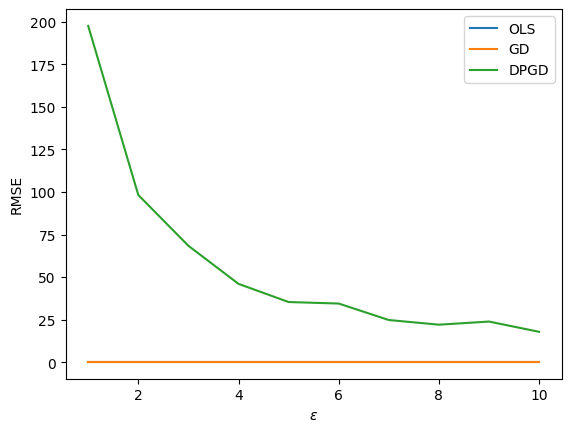

# Sensitivity Analysis for DP Gradient Descent

## 1. Gradient Form for Linear Regression
For linear regression $y = \beta_1x + \beta_0$, with loss function:
$L(\beta) = \frac{1}{n} \sum_{i=1}^n (y_i - (\beta_1x_i + \beta_0))^2$

The gradient components are:
* $\frac{\partial L}{\partial \beta_1} = -\frac{2}{n}\sum_{i=1}^n (y_i - (\beta_1x_i + \beta_0))x_i$
* $\frac{\partial L}{\partial \beta_0} = -\frac{2}{n}\sum_{i=1}^n (y_i - (\beta_1x_i + \beta_0))$

## 2. Gradient Sensitivity
Given the assumptions:
* $x_i, y_i \in [-1,1]$ (data bounds)
* $\beta_0, \beta_1 \in [-1,1]$ (parameter bounds)

For sensitivity, we need the L2 norm of gradient difference when changing one point:

* For any point $(x,y)$, its contribution to gradient is:
  * For $\beta_1$: $-\frac{2}{n}(y - (\beta_1x + \beta_0))x$
  * For $\beta_0$: $-\frac{2}{n}(y - (\beta_1x + \beta_0))$

* Maximum contribution difference (L2 norm):
  * $|y - (\beta_1x + \beta_0)| \leq 3$ (since $|y| \leq 1$ and $|\beta_1x + \beta_0| \leq 2$)
  * $|x| \leq 1$

Therefore L2 sensitivity of gradient: $\Delta_2 = \frac{6\sqrt{2}}{n}$

## 3. Privacy Budget for T Steps
From slides, for $(ε,δ)$-DP over T iterations:
* Using advanced composition theorem
* For T steps, per-step $ε_t = \frac{ε}{\sqrt{2T\ln(1/δ)}}$
* Total noise scale for each step: $σ = \frac{\Delta_2\sqrt{2\ln(1.25/δ)}}{ε_t}$

Substituting:
$σ = \frac{6\sqrt{2}}{n} \cdot \frac{\sqrt{2T\ln(1/δ)}}{ε} \cdot \sqrt{2\ln(1.25/δ)}$

This matches the form in the slides for DP-GD where $σ = \frac{2L\sqrt{2.92T\ln(1/δ)}}{ε}$ with $L=3$ (our Lipschitz constant).

In [ ]:
def dp_linreg_gd(x, y, step_size, num_steps, eps):
    '''
    Performs (eps,1/n)-DP linear regression using Gauss Perturbed Gradient Descent.
    '''
    n = y.size
    delta = 1/n
    
    # Compute noise scale based on sensitivity and number of steps

    sigma = (6* np.sqrt(2.92 * num_steps * np.log(1/delta))) / eps
    
    beta = np.zeros((2,1))
    beta_list = [beta]
    
    for i in range(num_steps):
        # Compute gradient
        yhat = beta[0]*x + beta[1]
        grad = np.zeros_like(beta)
        grad[0] = -2*np.mean((y - yhat)*x)
        grad[1] = -2*np.mean(y - yhat)
        
        # Add calibrated Gaussian noise
        noise = np.random.normal(0, sigma, size=(2,1))
        grad = grad + noise
        
        # Update beta
        beta = beta - step_size*grad
        beta_list.append(beta)
    
    return beta_list

plot: final iterate with GD 10 iterations. we see the median average as a function of epsilon. the curve will be decreasing, we hope. it should be eventually very clode to the curve of GD. 

the result - epsilon value which is good.

final question:
its not obvious if adding perturbation is the best choice. 



Even in this simplistic example, it turns out that the maximal $L^2$ sensitivity bound that can be obtained for the gradient from our assumptions is rather pessimistic. **Modify the `dp_lingreg_gd` code so as to be able to experiment with the gradient norm-clipping alternative used in DP-SGD. Can you find a value of the clipping which provides an improved accuracy?**

**Due to the addition of noise to the gradient at each step, it is not necessarily the case that using the same constant step size scheme and number of iterations leads to optimal results in terms of accuracy. Can you come up with a better solution while keeping the same $(\epsilon,\delta=1/n)$ DP budget (say, for a typical value of $\epsilon=3$)?** 

In [39]:
import numpy as np

def dp_linreg_gd_clipping(x, y, step_size, num_steps, eps, clip_norm):
    """
    Performs (ε, δ)-DP linear regression using Gaussian Perturbed Gradient Descent with gradient norm-clipping.

    Parameters:
    x (numpy.ndarray): Input features.
    y (numpy.ndarray): Target values.
    step_size (float): Step size for gradient descent.
    num_steps (int): Number of gradient descent steps.
    eps (float): Privacy budget.
    clip_norm (float): Clipping norm for gradients.

    Returns:
    list: List of beta estimates at each step.
    """
    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    # Compute sensitivity for clipped gradients
    delta = 1 / n
    sensitivity = (2 * clip_norm / n) * np.sqrt(num_steps)  # Clipped gradient sensitivity

    # Compute Gaussian noise scale
    sigma = (sensitivity * np.sqrt(2 * np.log(1 / delta))) / eps

    for _ in range(num_steps):
        yhat = beta[0] * x + beta[1]

        # Compute gradient
        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)

        # Clip gradient norm
        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = (grad / grad_norm) * clip_norm

        # Add Gaussian noise to gradient
        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise

        # Update beta
        beta = beta - step_size * grad
        beta_list.append(beta)

    return beta_list


In [ ]:
def dp_linreg_gd(x, y, step_size, num_steps, eps, clip_norm=1.0):
    """
    Performs (eps,1/n)-DP linear regression using Gauss Perturbed Gradient Descent.
    
    Parameters:
    x (numpy.ndarray): A 1D array of input features.
    y (numpy.ndarray): A 1D array of target values.
    step_size (positive float): Step size for gradient descent.
    num_steps (positive int): Number of gradient descent steps.
    eps (positive float): Privacy budget.
    clip_norm (float): Maximum norm for gradient clipping.
    
    Returns:
    list: List of beta estimates at each step.
    """
    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    # Compute noise scale using RDP-DP conversion
    delta = 1 / n
    sigma = (2 * np.sqrt(2.92 * num_steps * np.log(1 / delta))) / (eps * n)

    for i in range(num_steps):
        # Compute predictions
        yhat = beta[0] * x + beta[1]

        # Compute gradient
        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)

        # Clip gradients to bound influence of individual updates
        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = (grad / grad_norm) * clip_norm

        # Add Gaussian noise
        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise

        # Update beta using noisy gradient
        beta = beta - step_size * grad
        beta_list.append(beta)

    return beta_list

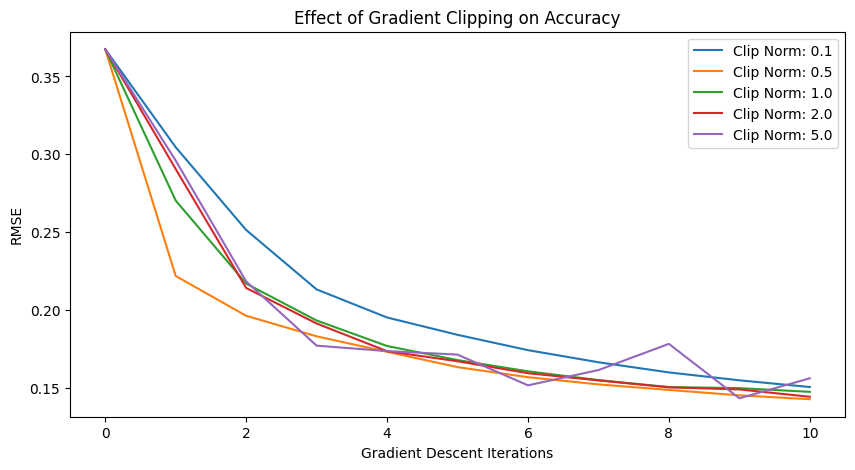

In [40]:
import matplotlib.pyplot as plt

# Function to evaluate RMSE of trained models
def evaluate_rmse(x, y, beta_list):
    rmse_values = []
    for beta in beta_list:
        yhat = beta[0] * x + beta[1]
        rmse = np.sqrt(np.mean((y - yhat) ** 2))
        rmse_values.append(rmse)
    return rmse_values

# Experimenting with different clipping values
clip_values = [0.1, 0.5, 1.0, 2.0, 5.0]
eps = 3  # Fixed privacy budget
num_steps = 10
step_size = 0.8

plt.figure(figsize=(10, 5))

for clip_norm in clip_values:
    beta_list = dp_linreg_gd_clipping(x, y, step_size, num_steps, eps, clip_norm)
    rmse_values = evaluate_rmse(x, y, beta_list)
    plt.plot(range(num_steps + 1), rmse_values, label=f"Clip Norm: {clip_norm}")

plt.xlabel("Gradient Descent Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.title("Effect of Gradient Clipping on Accuracy")
plt.show()


In [41]:
def dp_linreg_gd_adaptive(x, y, initial_step_size, num_steps, eps, clip_norm):
    """
    DP-GD with adaptive step size and gradient norm-clipping.

    Parameters:
    initial_step_size (float): Initial step size.
    num_steps (int): Number of gradient descent steps.

    Returns:
    list: List of beta estimates at each step.
    """
    n = y.size
    beta = np.zeros((2,1))
    beta_list = [beta]

    delta = 1 / n
    sensitivity = (2 * clip_norm / n) * np.sqrt(num_steps)
    sigma = (sensitivity * np.sqrt(2 * np.log(1 / delta))) / eps

    for t in range(1, num_steps + 1):
        step_size = initial_step_size / np.sqrt(t)  # Decaying step size
        yhat = beta[0] * x + beta[1]

        grad = np.zeros_like(beta)
        grad[0] = -2 * np.mean((y - yhat) * x)
        grad[1] = -2 * np.mean(y - yhat)

        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = (grad / grad_norm) * clip_norm

        noise = np.random.normal(0, sigma, size=grad.shape)
        grad += noise

        beta = beta - step_size * grad
        beta_list.append(beta)

    return beta_list


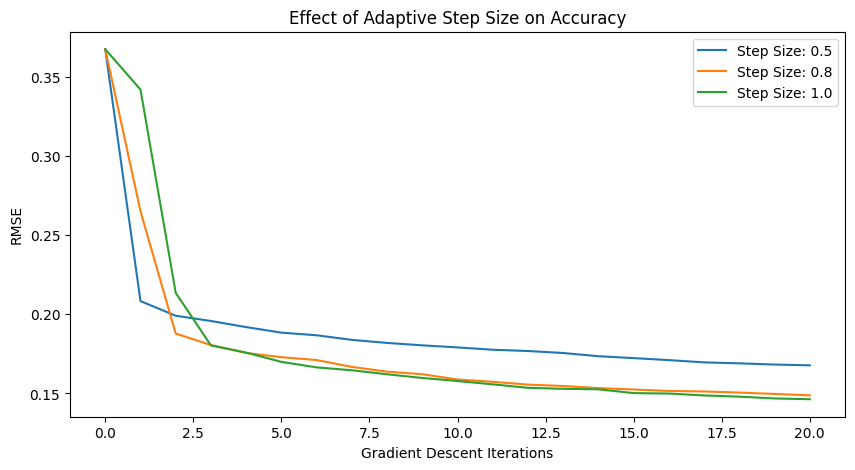

In [42]:
step_sizes = [0.5, 0.8, 1.0]
num_steps = 20  # Increasing iterations
clip_norm = 1.0  # Best from previous experiment

plt.figure(figsize=(10, 5))

for step_size in step_sizes:
    beta_list = dp_linreg_gd_adaptive(x, y, step_size, num_steps, eps, clip_norm)
    rmse_values = evaluate_rmse(x, y, beta_list)
    plt.plot(range(num_steps + 1), rmse_values, label=f"Step Size: {step_size}")

plt.xlabel("Gradient Descent Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.title("Effect of Adaptive Step Size on Accuracy")
plt.show()
